In [17]:
!nvidia-smi

Mon May  4 05:13:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   32C    P0             84W /  600W |     823MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [18]:
!pip install -q ultralytics lxml tqdm pyyaml scikit-learn pandas pillow matplotlib opencv-python

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os
import glob
import json
import math
import random
import shutil
from pathlib import Path
import xml.etree.ElementTree as ET

import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =========================
# 사용자가 수정할 경로
# =========================
# 이 경로는 "Bbox_0941 ~ Bbox_0980" 폴더들이 들어있는 상위 폴더여야 함
AIHUB_BBOX_ROOT = "/content/drive/MyDrive/capstone/data/sidewalk/bbox_16/Bbox_16_new"

# 작업 디렉토리
WORK_ROOT = "/content/aihub_bbox_yolo11s_edge_occ"
FLAT_ROOT = os.path.join(WORK_ROOT, "flat_dataset")
IMAGES_FLAT_DIR = os.path.join(FLAT_ROOT, "images")
LABELS_FLAT_DIR = os.path.join(FLAT_ROOT, "labels")

# 결과 저장
RUNS_DIR = os.path.join(WORK_ROOT, "runs")

os.makedirs(WORK_ROOT, exist_ok=True)
os.makedirs(FLAT_ROOT, exist_ok=True)
os.makedirs(IMAGES_FLAT_DIR, exist_ok=True)
os.makedirs(LABELS_FLAT_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)

print("AIHUB_BBOX_ROOT =", AIHUB_BBOX_ROOT)
print("WORK_ROOT       =", WORK_ROOT)

AIHUB_BBOX_ROOT = /content/drive/MyDrive/capstone/data/sidewalk/bbox_16/Bbox_16_new
WORK_ROOT       = /content/aihub_bbox_yolo11s_edge_occ


In [21]:
# 첫 XML의 <meta><labels> 순서를 그대로 class order로 쓰는 방식
# 다만 vehicle/hard 샘플 판단용 클래스는 미리 정의

VEHICLE_CLASSES = {
    "car", "bus", "truck", "bicycle", "motorcycle", "scooter",
    "stroller", "wheelchair", "carrier"
}

# 경계 차량 판단 기준: bbox가 프레임 가장자리 몇 px 이내면 edge-touching으로 간주
EDGE_TOUCH_PX = 4

# 너무 작은 박스 제거 기준 (아주 보수적으로)
MIN_BOX_W = 2
MIN_BOX_H = 2

# oversampling 강도
OCCLUDED_EXTRA_COPIES = 1      # occluded 포함 이미지면 +1
EDGE_VEHICLE_EXTRA_COPIES = 2  # edge vehicle 포함 이미지면 +2

# split 비율 (폴더 단위)
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

In [22]:
def safe_symlink_or_copy(src, dst):
    """
    가능하면 symlink, 실패하면 copy
    """
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    if os.path.exists(dst):
        return
    try:
        os.symlink(src, dst)
    except:
        shutil.copy2(src, dst)


def find_bbox_folders(root_dir):
    """
    Bbox_0941 ~ Bbox_0980 같은 폴더 검색
    """
    candidates = sorted([
        p for p in glob.glob(os.path.join(root_dir, "Bbox_*"))
        if os.path.isdir(p)
    ])
    return candidates


def get_single_xml_path(folder_path):
    xmls = glob.glob(os.path.join(folder_path, "*.xml"))
    if len(xmls) != 1:
        raise ValueError(f"[오류] {folder_path} 에 xml이 1개가 아님: {xmls}")
    return xmls[0]


def parse_class_order_from_first_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    labels = []
    for label_tag in root.findall("./meta/task/labels/label"):
        name_tag = label_tag.find("name")
        if name_tag is not None:
            labels.append(name_tag.text.strip())
    return labels


def clip_box(xtl, ytl, xbr, ybr, w, h):
    xtl = max(0.0, min(float(xtl), float(w)))
    ytl = max(0.0, min(float(ytl), float(h)))
    xbr = max(0.0, min(float(xbr), float(w)))
    ybr = max(0.0, min(float(ybr), float(h)))
    return xtl, ytl, xbr, ybr


def xyxy_to_yolo(xtl, ytl, xbr, ybr, w, h):
    bw = xbr - xtl
    bh = ybr - ytl
    xc = xtl + bw / 2.0
    yc = ytl + bh / 2.0
    return xc / w, yc / h, bw / w, bh / h


def touches_edge(xtl, ytl, xbr, ybr, w, h, margin=4):
    return (
        xtl <= margin or
        ytl <= margin or
        xbr >= (w - margin) or
        ybr >= (h - margin)
    )


def visualize_yolo_label(img_path, label_path, class_names, figsize=(10, 6)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, "r", encoding="utf-8") as f:
            lines = [x.strip() for x in f.readlines() if x.strip()]
        for line in lines:
            cls_id, xc, yc, bw, bh = line.split()
            cls_id = int(cls_id)
            xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                img, class_names[cls_id], (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2
            )

    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [23]:
bbox_folders = find_bbox_folders(AIHUB_BBOX_ROOT)
print("bbox folder count:", len(bbox_folders))
print("example:", bbox_folders[:3])

assert len(bbox_folders) > 0, "Bbox_XXXX 폴더를 찾지 못함"

first_xml = get_single_xml_path(bbox_folders[0])
CLASS_NAMES = parse_class_order_from_first_xml(first_xml)
CLASS2ID = {c: i for i, c in enumerate(CLASS_NAMES)}

print("num classes:", len(CLASS_NAMES))
print(CLASS_NAMES)

bbox folder count: 40
example: ['/content/drive/MyDrive/capstone/data/sidewalk/bbox_16/Bbox_16_new/Bbox_0941', '/content/drive/MyDrive/capstone/data/sidewalk/bbox_16/Bbox_16_new/Bbox_0942', '/content/drive/MyDrive/capstone/data/sidewalk/bbox_16/Bbox_16_new/Bbox_0943']
num classes: 29
['wheelchair', 'truck', 'tree_trunk', 'traffic_sign', 'traffic_light', 'traffic_light_controller', 'table', 'stroller', 'stop', 'scooter', 'potted_plant', 'power_controller', 'pole', 'person', 'parking_meter', 'movable_signage', 'motorcycle', 'kiosk', 'fire_hydrant', 'dog', 'chair', 'cat', 'carrier', 'car', 'bus', 'bollard', 'bicycle', 'bench', 'barricade']


In [24]:
manifest = []
missing_images = []
skipped_boxes_total = 0
kept_boxes_total = 0

for folder_path in tqdm(bbox_folders, desc="Converting XML -> YOLO"):
    group_name = os.path.basename(folder_path)  # ex) Bbox_0941
    xml_path = get_single_xml_path(folder_path)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    image_tags = root.findall("image")

    for image_tag in image_tags:
        img_name = image_tag.attrib["name"]
        w = int(float(image_tag.attrib["width"]))
        h = int(float(image_tag.attrib["height"]))

        src_img_path = os.path.join(folder_path, img_name)
        if not os.path.exists(src_img_path):
            missing_images.append(src_img_path)
            continue

        stem = Path(img_name).stem
        out_img_name = f"{group_name}__{img_name}"
        out_label_name = f"{group_name}__{stem}.txt"

        out_img_path = os.path.join(IMAGES_FLAT_DIR, out_img_name)
        out_label_path = os.path.join(LABELS_FLAT_DIR, out_label_name)

        safe_symlink_or_copy(src_img_path, out_img_path)

        yolo_lines = []
        n_boxes = 0
        n_occluded_boxes = 0
        n_edge_boxes = 0
        n_edge_vehicle_boxes = 0

        has_occluded = False
        has_edge_any = False
        has_edge_vehicle = False

        for box_tag in image_tag.findall("box"):
            label = box_tag.attrib["label"].strip()
            if label not in CLASS2ID:
                continue

            occluded = int(box_tag.attrib.get("occluded", "0"))
            xtl = float(box_tag.attrib["xtl"])
            ytl = float(box_tag.attrib["ytl"])
            xbr = float(box_tag.attrib["xbr"])
            ybr = float(box_tag.attrib["ybr"])

            # 좌표 clip
            xtl, ytl, xbr, ybr = clip_box(xtl, ytl, xbr, ybr, w, h)

            bw = xbr - xtl
            bh = ybr - ytl

            # 너무 작은 박스만 제거
            if bw < MIN_BOX_W or bh < MIN_BOX_H:
                skipped_boxes_total += 1
                continue

            edge_flag = touches_edge(xtl, ytl, xbr, ybr, w, h, margin=EDGE_TOUCH_PX)

            cls_id = CLASS2ID[label]
            xc_n, yc_n, bw_n, bh_n = xyxy_to_yolo(xtl, ytl, xbr, ybr, w, h)

            yolo_lines.append(f"{cls_id} {xc_n:.6f} {yc_n:.6f} {bw_n:.6f} {bh_n:.6f}")
            kept_boxes_total += 1
            n_boxes += 1

            if occluded == 1:
                has_occluded = True
                n_occluded_boxes += 1

            if edge_flag:
                has_edge_any = True
                n_edge_boxes += 1

            if edge_flag and label in VEHICLE_CLASSES:
                has_edge_vehicle = True
                n_edge_vehicle_boxes += 1

        # 빈 label 파일도 생성 (혹시 필터링 후 0개일 수 있으므로)
        with open(out_label_path, "w", encoding="utf-8") as f:
            if len(yolo_lines) > 0:
                f.write("\n".join(yolo_lines))

        manifest.append({
            "group": group_name,
            "xml_path": xml_path,
            "src_img_path": src_img_path,
            "out_img_path": out_img_path,
            "out_label_path": out_label_path,
            "img_name": img_name,
            "width": w,
            "height": h,
            "n_boxes": n_boxes,
            "n_occluded_boxes": n_occluded_boxes,
            "n_edge_boxes": n_edge_boxes,
            "n_edge_vehicle_boxes": n_edge_vehicle_boxes,
            "has_occluded": has_occluded,
            "has_edge_any": has_edge_any,
            "has_edge_vehicle": has_edge_vehicle,
        })

manifest_df = pd.DataFrame(manifest)
manifest_csv = os.path.join(WORK_ROOT, "manifest.csv")
manifest_df.to_csv(manifest_csv, index=False, encoding="utf-8-sig")

print("done")
print("missing_images:", len(missing_images))
print("kept_boxes_total:", kept_boxes_total)
print("skipped_boxes_total:", skipped_boxes_total)
print("manifest saved:", manifest_csv)
print(manifest_df.head())

Converting XML -> YOLO: 100%|██████████| 40/40 [00:02<00:00, 14.83it/s]

done
missing_images: 0
kept_boxes_total: 148246
skipped_boxes_total: 3
manifest saved: /content/aihub_bbox_yolo11s_edge_occ/manifest.csv
       group                                           xml_path  \
0  Bbox_0941  /content/drive/MyDrive/capstone/data/sidewalk/...   
1  Bbox_0941  /content/drive/MyDrive/capstone/data/sidewalk/...   
2  Bbox_0941  /content/drive/MyDrive/capstone/data/sidewalk/...   
3  Bbox_0941  /content/drive/MyDrive/capstone/data/sidewalk/...   
4  Bbox_0941  /content/drive/MyDrive/capstone/data/sidewalk/...   

                                        src_img_path  \
0  /content/drive/MyDrive/capstone/data/sidewalk/...   
1  /content/drive/MyDrive/capstone/data/sidewalk/...   
2  /content/drive/MyDrive/capstone/data/sidewalk/...   
3  /content/drive/MyDrive/capstone/data/sidewalk/...   
4  /content/drive/MyDrive/capstone/data/sidewalk/...   

                                        out_img_path  \
0  /content/aihub_bbox_yolo11s_edge_occ/flat_data...   
1  /content

In [25]:
print("num images:", len(manifest_df))
print("num groups :", manifest_df["group"].nunique())
print()

print("has_occluded images      :", int(manifest_df["has_occluded"].sum()))
print("has_edge_any images      :", int(manifest_df["has_edge_any"].sum()))
print("has_edge_vehicle images  :", int(manifest_df["has_edge_vehicle"].sum()))
print()

print("avg boxes/image:", manifest_df["n_boxes"].mean())
print("avg occluded boxes/image:", manifest_df["n_occluded_boxes"].mean())
print("avg edge vehicle boxes/image:", manifest_df["n_edge_vehicle_boxes"].mean())

num images: 12370
num groups : 40

has_occluded images      : 12282
has_edge_any images      : 11394
has_edge_vehicle images  : 6405

avg boxes/image: 11.984316895715441
avg occluded boxes/image: 6.680921584478577
avg edge vehicle boxes/image: 0.6746160064672595


/content/aihub_bbox_yolo11s_edge_occ/flat_dataset/images/Bbox_0953__MP_SEL_260330_B115346.jpg
/content/aihub_bbox_yolo11s_edge_occ/flat_dataset/labels/Bbox_0953__MP_SEL_260330_B115346.txt


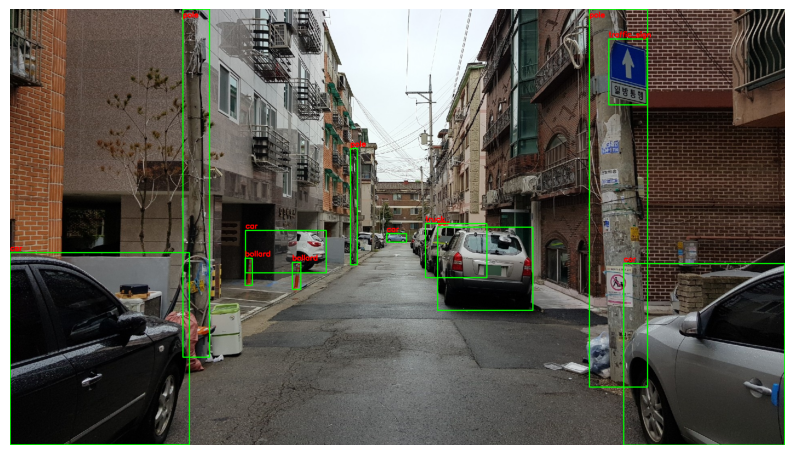

In [26]:
sample_row = manifest_df.sample(1, random_state=SEED).iloc[0]
print(sample_row["out_img_path"])
print(sample_row["out_label_path"])
visualize_yolo_label(sample_row["out_img_path"], sample_row["out_label_path"], CLASS_NAMES)

In [27]:
groups = sorted(manifest_df["group"].unique().tolist())
rng = random.Random(SEED)
rng.shuffle(groups)

n_total = len(groups)
n_train = int(round(n_total * TRAIN_RATIO))
n_val   = int(round(n_total * VAL_RATIO))
n_test  = n_total - n_train - n_val

train_groups = set(groups[:n_train])
val_groups   = set(groups[n_train:n_train+n_val])
test_groups  = set(groups[n_train+n_val:])

print("n_total groups:", n_total)
print("train groups  :", len(train_groups))
print("val groups    :", len(val_groups))
print("test groups   :", len(test_groups))

train_df = manifest_df[manifest_df["group"].isin(train_groups)].copy()
val_df   = manifest_df[manifest_df["group"].isin(val_groups)].copy()
test_df  = manifest_df[manifest_df["group"].isin(test_groups)].copy()

print("train images:", len(train_df))
print("val images  :", len(val_df))
print("test images :", len(test_df))

n_total groups: 40
train groups  : 32
val groups    : 4
test groups   : 4
train images: 9974
val images  : 1199
test images : 1197


In [28]:
train_txt = os.path.join(WORK_ROOT, "train.txt")
val_txt   = os.path.join(WORK_ROOT, "val.txt")
test_txt  = os.path.join(WORK_ROOT, "test.txt")

hard_train_txt = os.path.join(WORK_ROOT, "train_hard_only.txt")
edge_test_txt  = os.path.join(WORK_ROOT, "test_edge_vehicle.txt")
occ_test_txt   = os.path.join(WORK_ROOT, "test_occluded.txt")

def write_image_list_txt(df, txt_path, oversample=False):
    count_lines = 0
    with open(txt_path, "w", encoding="utf-8") as f:
        for _, row in df.iterrows():
            repeat = 1
            if oversample:
                if row["has_occluded"]:
                    repeat += OCCLUDED_EXTRA_COPIES
                if row["has_edge_vehicle"]:
                    repeat += EDGE_VEHICLE_EXTRA_COPIES

            for _ in range(repeat):
                f.write(row["out_img_path"] + "\n")
                count_lines += 1
    return count_lines

train_line_count = write_image_list_txt(train_df, train_txt, oversample=True)
val_line_count   = write_image_list_txt(val_df, val_txt, oversample=False)
test_line_count  = write_image_list_txt(test_df, test_txt, oversample=False)

hard_only_df = train_df[(train_df["has_occluded"]) | (train_df["has_edge_vehicle"])].copy()
hard_train_line_count = write_image_list_txt(hard_only_df, hard_train_txt, oversample=True)

edge_test_df = test_df[test_df["has_edge_vehicle"]].copy()
occ_test_df  = test_df[test_df["has_occluded"]].copy()

_ = write_image_list_txt(edge_test_df, edge_test_txt, oversample=False)
_ = write_image_list_txt(occ_test_df, occ_test_txt, oversample=False)

print("train.txt lines     :", train_line_count)
print("val.txt lines       :", val_line_count)
print("test.txt lines      :", test_line_count)
print("hard_train lines    :", hard_train_line_count)
print("edge test images    :", len(edge_test_df))
print("occluded test images:", len(occ_test_df))

train.txt lines     : 30158
val.txt lines       : 1199
test.txt lines      : 1197
hard_train lines    : 30093
edge test images    : 633
occluded test images: 1187


In [29]:
data_yaml = {
    "path": FLAT_ROOT,
    "train": train_txt,
    "val": val_txt,
    "test": test_txt,
    "names": {i: name for i, name in enumerate(CLASS_NAMES)}
}

data_yaml_path = os.path.join(WORK_ROOT, "data.yaml")
with open(data_yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("saved:", data_yaml_path)
print(open(data_yaml_path, "r", encoding="utf-8").read())

saved: /content/aihub_bbox_yolo11s_edge_occ/data.yaml
path: /content/aihub_bbox_yolo11s_edge_occ/flat_dataset
train: /content/aihub_bbox_yolo11s_edge_occ/train.txt
val: /content/aihub_bbox_yolo11s_edge_occ/val.txt
test: /content/aihub_bbox_yolo11s_edge_occ/test.txt
names:
  0: wheelchair
  1: truck
  2: tree_trunk
  3: traffic_sign
  4: traffic_light
  5: traffic_light_controller
  6: table
  7: stroller
  8: stop
  9: scooter
  10: potted_plant
  11: power_controller
  12: pole
  13: person
  14: parking_meter
  15: movable_signage
  16: motorcycle
  17: kiosk
  18: fire_hydrant
  19: dog
  20: chair
  21: cat
  22: carrier
  23: car
  24: bus
  25: bollard
  26: bicycle
  27: bench
  28: barricade



In [30]:
data_hard_yaml = {
    "path": FLAT_ROOT,
    "train": hard_train_txt,
    "val": val_txt,
    "test": test_txt,
    "names": {i: name for i, name in enumerate(CLASS_NAMES)}
}

data_hard_yaml_path = os.path.join(WORK_ROOT, "data_hard.yaml")
with open(data_hard_yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_hard_yaml, f, sort_keys=False, allow_unicode=True)

print("saved:", data_hard_yaml_path)
print(open(data_hard_yaml_path, "r", encoding="utf-8").read())

saved: /content/aihub_bbox_yolo11s_edge_occ/data_hard.yaml
path: /content/aihub_bbox_yolo11s_edge_occ/flat_dataset
train: /content/aihub_bbox_yolo11s_edge_occ/train_hard_only.txt
val: /content/aihub_bbox_yolo11s_edge_occ/val.txt
test: /content/aihub_bbox_yolo11s_edge_occ/test.txt
names:
  0: wheelchair
  1: truck
  2: tree_trunk
  3: traffic_sign
  4: traffic_light
  5: traffic_light_controller
  6: table
  7: stroller
  8: stop
  9: scooter
  10: potted_plant
  11: power_controller
  12: pole
  13: person
  14: parking_meter
  15: movable_signage
  16: motorcycle
  17: kiosk
  18: fire_hydrant
  19: dog
  20: chair
  21: cat
  22: carrier
  23: car
  24: bus
  25: bollard
  26: bicycle
  27: bench
  28: barricade



In [31]:
edge_test_yaml = {
    "path": FLAT_ROOT,
    "train": train_txt,
    "val": edge_test_txt,
    "test": edge_test_txt,
    "names": {i: name for i, name in enumerate(CLASS_NAMES)}
}
edge_test_yaml_path = os.path.join(WORK_ROOT, "data_edge_test.yaml")
with open(edge_test_yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(edge_test_yaml, f, sort_keys=False, allow_unicode=True)

occ_test_yaml = {
    "path": FLAT_ROOT,
    "train": train_txt,
    "val": occ_test_txt,
    "test": occ_test_txt,
    "names": {i: name for i, name in enumerate(CLASS_NAMES)}
}
occ_test_yaml_path = os.path.join(WORK_ROOT, "data_occ_test.yaml")
with open(occ_test_yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(occ_test_yaml, f, sort_keys=False, allow_unicode=True)

print("saved:", edge_test_yaml_path)
print("saved:", occ_test_yaml_path)

saved: /content/aihub_bbox_yolo11s_edge_occ/data_edge_test.yaml
saved: /content/aihub_bbox_yolo11s_edge_occ/data_occ_test.yaml


In [32]:
BASE_MODEL = "yolo11s.pt"

model = YOLO(BASE_MODEL)

train_results = model.train(
    data=data_yaml_path,
    project=RUNS_DIR,
    name="yolo11s_edge_occ_stage1_safe",

    epochs=50,
    imgsz=480,
    batch=8,              # 먼저 안정적으로
    workers=2,
    device=0,

    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,

    patience=20,
    cos_lr=True,
    amp=True,
    cache="disk",         # ram 대신 disk
    multi_scale=False,    # 일단 끔

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.20,
    scale=0.60,
    shear=0.0,
    perspective=0.0005,
    fliplr=0.5,
    flipud=0.0,
    mosaic=1.0,
    mixup=0.05,
    copy_paste=0.0,
    close_mosaic=10,

    rect=False,
    plots=True,
    save=True,
    save_period=10,
    verbose=True,
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/aihub_bbox_yolo11s_edge_occ/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11s_edge_occ_stage1_safe-2, nbs=64, nms=False, 

KeyboardInterrupt: 

In [ ]:
stage1_dir = os.path.join(RUNS_DIR, "yolo11s_edge_occ_stage1")
stage1_best = os.path.join(stage1_dir, "weights", "best.pt")
stage1_last = os.path.join(stage1_dir, "weights", "last.pt")

print("stage1_best:", stage1_best, os.path.exists(stage1_best))
print("stage1_last:", stage1_last, os.path.exists(stage1_last))

In [ ]:
import os, glob

print("RUNS_DIR =", RUNS_DIR)
all_pts = glob.glob(os.path.join(RUNS_DIR, "*", "weights", "*.pt"))
for p in sorted(all_pts):
    print(p)

In [ ]:
import os

stage1_dir = os.path.join(RUNS_DIR, "yolo11s_edge_occ_stage1_safe")
stage1_best = os.path.join(stage1_dir, "weights", "best.pt")
stage1_last = os.path.join(stage1_dir, "weights", "last.pt")

print("stage1_best exists:", os.path.exists(stage1_best), stage1_best)
print("stage1_last exists:", os.path.exists(stage1_last), stage1_last)

In [ ]:
resume_weight = stage1_best if os.path.exists(stage1_best) else stage1_last
print("resume_weight =", resume_weight)

hard_model = YOLO(resume_weight)

In [ ]:
import os
from ultralytics import YOLO

# 1차 학습 폴더 이름
stage1_dir = os.path.join(RUNS_DIR, "yolo11s_edge_occ_stage1_safe")

stage1_best = os.path.join(stage1_dir, "weights", "best.pt")
stage1_last = os.path.join(stage1_dir, "weights", "last.pt")

print("checking weights...")
print("best:", stage1_best, os.path.exists(stage1_best))
print("last:", stage1_last, os.path.exists(stage1_last))

if os.path.exists(stage1_best):
    resume_weight = stage1_best
elif os.path.exists(stage1_last):
    resume_weight = stage1_last
else:
    raise FileNotFoundError(
        "stage1 weight가 없습니다. "
        "1차 학습이 실패했거나, stage1_dir 이름이 잘못되었습니다."
    )

print("Using resume_weight:", resume_weight)

hard_model = YOLO(resume_weight)

hard_results = hard_model.train(
    data=data_hard_yaml_path,
    project=RUNS_DIR,
    name="yolo11s_edge_occ_stage2_hardft",

    epochs=50,
    imgsz=480,
    batch=8,
    workers=2,
    device=0,

    pretrained=False,
    optimizer="AdamW",
    lr0=0.0003,
    lrf=0.01,
    weight_decay=0.0005,

    patience=10,
    cos_lr=True,
    amp=True,
    cache="disk",
    multi_scale=False,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=0.0,
    translate=0.10,
    scale=0.35,
    shear=0.0,
    perspective=0.0003,
    fliplr=0.5,
    flipud=0.0,
    mosaic=0.3,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=0,

    rect=False,
    plots=True,
    save=True,
    save_period=5,
    verbose=True,
)

In [ ]:
stage2_dir = os.path.join(RUNS_DIR, "yolo11s_edge_occ_stage2_hardft2")
final_best = os.path.join(stage2_dir, "weights", "best.pt")
final_last = os.path.join(stage2_dir, "weights", "last.pt")

print("final_best:", final_best, os.path.exists(final_best))
print("final_last:", final_last, os.path.exists(final_last))

In [ ]:
import os

print(os.path.exists("/content/aihub_bbox_yolo11s_edge_occ/runs/"))
print(os.listdir("/content/aihub_bbox_yolo11s_edge_occ/runs/"))

In [ ]:
runs_dir = "/content/aihub_bbox_yolo11s_edge_occ/runs"

for d in os.listdir(runs_dir):
    print(d)

In [ ]:
import os

target_dir = "/content/aihub_bbox_yolo11s_edge_occ/runs/yolo11s_edge_occ_stage2_hardft"

print(os.listdir(target_dir))
print(os.listdir(os.path.join(target_dir, "weights")))

In [ ]:
stage2_dir = "/content/aihub_bbox_yolo11s_edge_occ/runs/yolo11s_edge_occ_stage2_hardft"  # ← 실제 폴더로 수정

final_best = os.path.join(stage2_dir, "weights", "best.pt")

print("exists:", os.path.exists(final_best))

In [ ]:
final_model = YOLO(final_best)

metrics_test = final_model.val(
    data=data_yaml_path,
    split="test",
    imgsz=960,
    batch=16,
    conf=0.001,
    iou=0.6,
    device=0,
    plots=True,
    save_json=False,
)

print(metrics_test)

In [ ]:
metrics_edge = final_model.val(
    data=edge_test_yaml_path,
    split="test",
    imgsz=960,
    batch=16,
    conf=0.001,
    iou=0.6,
    device=0,
    plots=True,
    save_json=False,
)

print(metrics_edge)

In [ ]:
metrics_occ = final_model.val(
    data=occ_test_yaml_path,
    split="test",
    imgsz=960,
    batch=16,
    conf=0.001,
    iou=0.6,
    device=0,
    plots=True,
    save_json=False,
)

print(metrics_occ)

In [ ]:
sample_imgs = test_df.sample(5, random_state=SEED)["out_img_path"].tolist()
sample_imgs

In [ ]:
pred_dir = os.path.join(WORK_ROOT, "pred_examples")
os.makedirs(pred_dir, exist_ok=True)

pred_results = final_model.predict(
    source=sample_imgs,
    imgsz=960,
    conf=0.20,
    iou=0.6,
    device=0,
    save=True,
    project=pred_dir,
    name="demo",
    exist_ok=True
)

print("saved to:", os.path.join(pred_dir, "demo"))

In [ ]:
demo_dir = os.path.join(pred_dir, "demo")
pred_paths = sorted(glob.glob(os.path.join(demo_dir, "*.jpg")))

for p in pred_paths[:5]:
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
zip_path = "/content/yolo11s_edge_occ_results.zip"
!zip -r -q $zip_path $RUNS_DIR $WORK_ROOT/*.yaml $WORK_ROOT/*.txt $WORK_ROOT/manifest.csv
print("zip saved:", zip_path)

In [ ]:
from google.colab import files
files.download("/content/yolo11s_edge_occ_results.zip")